In [ ]:
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
import pandas as pd
from sparse import COO

from lmfit.lineshapes import gaussian

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pathlib import Path
import itertools
import warnings

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data

from histpy import Histogram, Axes, Axis, HealpixAxis
import mhealpy as hp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from threeML import Model, Powerlaw, Gaussian

In [2]:
# image_response = Histogram.open('reparam_spectral_response_example.h5')

# dr = DetectorResponse(edges = image_response.axes[1:],
#                       contents = image_response.slice[1].contents.reshape(5,5),
#                       sparse = False,
#                       unit = image_response.unit,
#                       coord = None)

In [3]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5'

In [4]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)
    dr = f[pix]

{'_file': <HDF5 file "DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (3 members)>, '_unit': Unit("cm2"), '_sparse': True, '_axes': <histpy.axes.Axes object at 0x2ad107130>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 3, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 4503599627370496}


{'_file': <HDF5 file "DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (3 members)>, '_unit': Unit("cm2"), '_sparse': True, '_axes': <histpy.axes.Axes object at 0x11013b010>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 3, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 4503599627370496}


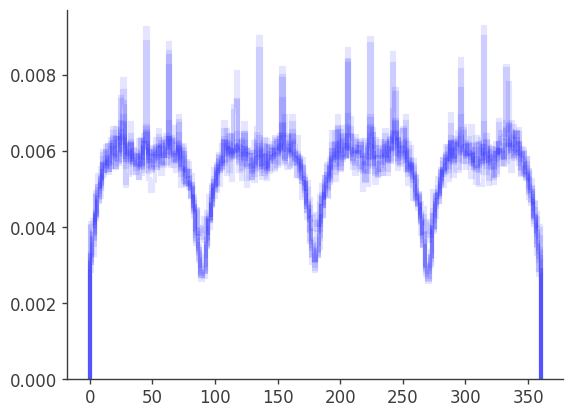

In [4]:
with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)

    for p in np.arange(0, 10):
        hist = f[p].project('Zeta')
        counts = hist.contents.todense()
        bins = hist.axis.edges
        plt.stairs(counts/np.sum(counts), bins.value, lw=3, alpha=0.1, color='b')
    # plt.yscale('log')

In [5]:
def get_vector(Phi_sc, Theta_sc):
    """
    Construct a 3D vector from sine-cosine representations of angular coordinates using NumPy arrays.

    The inputs, Phi_sc and Theta_sc, are expected to be produced by '_sc_stacker', so that each
    contains both the sine and cosine values of the corresponding angle.

    Parameters:
        Phi_sc (ndarray): Sine-cosine representation of the phi angle.
        Theta_sc (ndarray): Sine-cosine representation of the theta angle.

    Returns:
        ndarray: A 3D vector computed from the provided sine-cosine components.
    """
    x = Theta_sc[0] * Phi_sc[1]
    y = Theta_sc[0] * Phi_sc[0]
    z = Theta_sc[1]

    return np.stack((x, y, z), axis=-1)

def sc_stacker(t):
    """
    Create a sine-cosine NumPy array from an angle.

    Parameters:
        t (ndarray): A NumPy array of angles.

    Returns:
        ndarray: A vertically stacked array containing [sin(t), cos(t)] ("sine-cosine representation").
    """
    return np.vstack((np.sin(t), np.cos(t)))

def pix_to_ang(pix, nside=nside):
    # Added code to convert healpy pixel to angles in radians
    NuLambda_sc = np.atleast_1d(pix)
    Nu_sc, Lambda_sc = hp.pix2ang(nside=nside, ipix=NuLambda_sc)
    Nu_sc = sc_stacker(Nu_sc)
    Lambda_sc = sc_stacker(Lambda_sc)

    return (Nu_sc, Lambda_sc)

def convert_conventions(NuLambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc):
    """
    Convert classical to relative coordinate convention.
    
    Parameters:
        NuLambda_sc (ndarray): Healpix representation of the initial photon direction in spacecraft coordinates.
        Ei (ndarray): Initial energy.
        Em (ndarray): Measured energy.
        Phi (ndarray): Scattering angle.
        Psi_sc, Chi_sc (ndarray): Angular representation (radians) of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Epsilon, Theta ARM, Zeta) in relative coordinates
    """
    Eps = Em/Ei - 1

    # Data preprocessing
    Nu_sc, Lambda_sc = pix_to_ang(NuLambda_sc)
    Psi_sc = sc_stacker(Psi_sc)
    Chi_sc = sc_stacker(Chi_sc)

    source = get_vector(Nu_sc, Lambda_sc)
    scatter = get_vector(Psi_sc, Chi_sc)

    Phi_geo = np.arccos(np.clip(np.sum(source * scatter, axis=1), -1., 1.))     # np.arccos input range is -1 to +1

    xaxis = np.array([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = np.cross(pz, np.broadcast_to(xaxis, pz.shape), axis=1)
    px /= np.linalg.norm(px, axis=1, keepdims=True)
    py = np.cross(pz, px, axis=1)
    py /= np.linalg.norm(py, axis=1, keepdims=True)

    proj_x = np.sum(scatter * px, axis=1)
    proj_y = np.sum(scatter * py, axis=1)

    Zeta = np.arctan2(proj_y, proj_x)
    Zeta = np.where(Zeta < 0, Zeta + 2*np.pi, Zeta)

    return (Eps, Phi_geo - Phi, Zeta)
    # return (Phi_geo - Phi, Zeta)

def reverse_conventions(NuLambda_sc, Ei, Eps, Phi, Theta, Zeta):
    """
    Convert relative to classical coordinate convention using NumPy arrays.
    
    Parameters:
        NuLambda_sc (ndarray): Healpix representation of the initial photon direction in spacecraft coordinates.
        Ei (ndarray): Initial energy.
        Eps (ndarray): Relative measured energy.
        Phi (ndarray): Scattering angle.
        Theta, Zeta (ndarray): Angular representation (radians) of the scattering direction in relative spacecraft coordinates.
        
    Returns:
        tuple: (Em, Psi, Chi) in classical coordinates
    """
    Em = Ei * (Eps + 1)

    Psi_sc = sc_stacker(Zeta)
    Chi_sc = sc_stacker(np.pi - (Theta + Phi))
    scatter_base = get_vector(Psi_sc, Chi_sc)

    # Data preprocessing
    Nu_sc, Lambda_sc = pix_to_ang(NuLambda_sc)

    source = get_vector(Nu_sc, Lambda_sc)
    xaxis = np.array([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = np.cross(pz, np.broadcast_to(xaxis, pz.shape), axis=1)
    px /= np.linalg.norm(px, axis=1, keepdims=True)
    py = np.cross(pz, px, axis=1)
    py /= np.linalg.norm(py, axis=1, keepdims=True)

    change_basis = np.stack((px, py, pz), axis=2)
    scatter = np.matmul(change_basis, scatter_base[..., np.newaxis]).squeeze(-1)
    scatter /= np.linalg.norm(scatter, axis=1, keepdims=True)

    Psi = np.arctan2(scatter[:, 1], scatter[:, 0])
    Psi = np.where(Psi < 0, Psi + 2*np.pi, Psi)

    Chi = np.arccos(np.clip(scatter[:, 2], -1., 1.))        # np.arccos input range is -1 to +1

    return (Em, Psi, Chi)
    # return (Psi, Chi)

In [6]:
def transform_PsiChi_to_ThetaZeta(Phi, Psi_sc, Chi_sc):
    NuLambda_sc = np.array([0])
    Ei = 511
    Em = 511
    _, Theta, Zeta = convert_conventions(NuLambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc)
    return (Theta, Zeta)

def transform_ThetaZeta_to_PsiChi(Phi, Theta, Zeta):
    NuLambda_sc = np.array([0])
    Ei = 511
    Eps = 0
    _, Psi_sc, Chi_sc = reverse_conventions(NuLambda_sc, Ei, Eps, Phi, Theta, Zeta)
    return (Psi_sc, Chi_sc)

In [7]:
Phi = np.deg2rad(30)
Theta = np.deg2rad(15)
Zeta = np.deg2rad(10)

print(Theta, Zeta)

Psi_sc, Chi_sc = transform_ThetaZeta_to_PsiChi(Phi, Theta, Zeta)
transform_PsiChi_to_ThetaZeta(Phi, Psi_sc, Chi_sc)

0.2617993877991494 0.17453292519943295


(array([0.26179939]), array([0.17453293]))

In [8]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Ei':
            key = label

        elif label == 'Eps':
            key = 'Em'

        elif label == 'Phi':
            key = label

        elif label == 'Theta':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            # NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            Theta, Zeta = transform_PsiChi_to_ThetaZeta(target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
    
        elif label == 'Zeta':
            continue

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    print(indices, weights)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        pass
    else:
        warnings.warn('len(target) != len(dr.axes)')
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

In [9]:
convert_conventions(NuLambda_sc, target['Ei'], target['Em'], target['Phi'].to(u.rad).value, target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)

NameError: name 'NuLambda_sc' is not defined

In [10]:
dr.axes['Ei'].edges[33]

<Quantity 476.394 keV>

In [11]:
np.max(dr.slice[33,90,10,:,:,:,:].contents)

0.02927198973111927

In [13]:
Ei0 = 511 * u.keV #505.11474*u.keV
Em0 = 511 * u.keV #505.11474*u.keV
Phi0 = 20 * u.deg
Psi_sc0 = 77.5 * u.deg
Chi_sc0 = 90 * u.deg
# for Psi_sc0 in np.arange(70, 110)*u.deg:
target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0}
hist = dr.project('Ei', 'Eps', 'Phi')

# target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0, 'Psi_sc': Psi_sc0, 'Chi_sc': Chi_sc0}
# hist = dr.project('Ei', 'Eps', 'Phi', 'Theta', 'Zeta')

# target = {'Ei': Ei0, 'Em': Em0}
# hist = dr.slice[:,:,10,:,:,:,:].project('Ei', 'Eps')

dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
print(Psi_sc0, get_interp_response(dr2, target))
# plt.imshow(get_interp_response(dr2, target).todense())

[array([33, 34]), array([90, 89]), array([ 9, 10])] [array([0.90105938, 0.09894062]), <Quantity [0.4999955, 0.4999955]>, array([0.61110012, 0.38889988])]
77.5 deg 0.3493929013842522


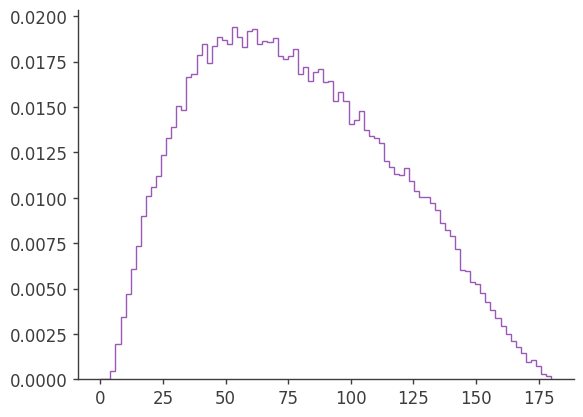

In [13]:
hist = dr.project('Phi')
counts = hist.contents.todense()
bins = hist.axis.edges
plt.stairs(counts/np.sum(counts), bins.value)
# plt.yscale('log')

In [28]:
Ei0 = 505.11474*u.keV
Em0 = (1 - 0.00555555) * 505.11474*u.keV
Phi0 = 10 * u.deg
target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0}

hist = dr.project('Ei', 'Eps')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
get_all_interp_weights(dr2, target)

([array([32, 33]), array([89, 90])],
 [array([8.08905678e-08, 9.99999919e-01]),
  <Quantity [ 1.00000e+00, -9.00009e-06]>])

In [15]:
dr.axes['Eps'].centers

<Quantity [-0.9944445 , -0.9833335 , -0.9722225 , -0.9611115 , -0.95      ,
           -0.9388885 , -0.9277775 , -0.9166665 , -0.9055555 , -0.8944445 ,
           -0.8833335 , -0.8722225 , -0.8611115 , -0.85      , -0.8388885 ,
           -0.8277775 , -0.8166665 , -0.8055555 , -0.7944445 , -0.7833335 ,
           -0.7722225 , -0.7611115 , -0.75      , -0.7388885 , -0.7277775 ,
           -0.7166665 , -0.7055555 , -0.6944445 , -0.6833335 , -0.6722225 ,
           -0.6611115 , -0.65      , -0.6388885 , -0.6277775 , -0.6166665 ,
           -0.6055555 , -0.5944445 , -0.5833335 , -0.5722225 , -0.5611115 ,
           -0.55      , -0.5388885 , -0.5277775 , -0.5166665 , -0.5055555 ,
           -0.4944445 , -0.4833335 , -0.4722225 , -0.4611115 , -0.45      ,
           -0.4388885 , -0.4277775 , -0.4166665 , -0.4055555 , -0.3944445 ,
           -0.3833335 , -0.3722225 , -0.3611115 , -0.35      , -0.3388885 ,
           -0.3277775 , -0.3166665 , -0.3055555 , -0.2944445 , -0.2833335 ,
           -

In [16]:
dr.get_effective_area(400*u.keV)

<Quantity 104.2147474 cm2>

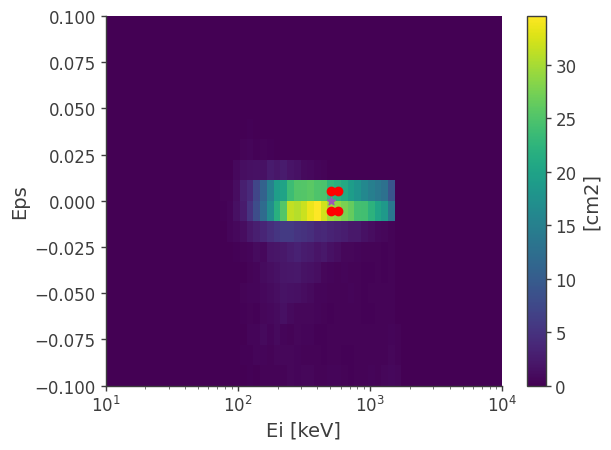

In [16]:
fig, ax = plt.subplots()
dr.project('Ei', 'Eps').draw(ax=ax)
ax.scatter(Ei0, dr.transform_Em_to_Eps(Em0, Ei0), marker='*')

target = {'Ei': Ei0, 'Em': Em0}
hist = dr.project('Ei', 'Eps')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
dr2.get_interp_response(target)

for e1 in dr2.neighbors['Ei']:
    for e2 in dr2.neighbors['Eps']:
        ax.scatter(e1, e2, c='r')

ax.set_ylim([-0.1, 0.1])
plt.show()

In [72]:
Phi0 = 10 * u.deg
target = {'Phi': Phi0}

hist = dr.project('Phi')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
get_all_interp_weights(dr2, target)

([array([4, 5])], [array([0.55556242, 0.44443758])])

In [18]:
def get_nearest_neighbors(dr, target: dict, indices=None):
    neighbors = {}
    for idx, label in zip(indices, dr.axes.labels):
        neighbors[label] = dr.axes[label].centers[idx]
    return neighbors

In [106]:
dr2.neighbors

{'Theta': <Quantity [-10.05589 ,  -8.044695] deg>,
 'Zeta': <Quantity [115.6425, 117.6535] deg>}

[array([ 9, 10])] [array([0.61110012, 0.38889988])]



WARNING UserWarning: len(target) != len(dr.axes)



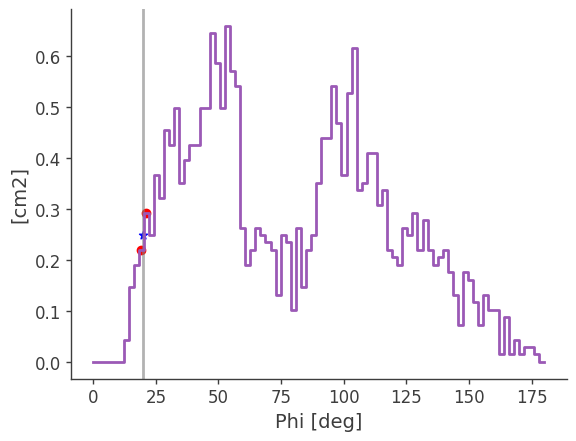

In [30]:
key = 'Phi'
Phi0 = 20 * u.deg
Psi_sc0 = 77.5 * u.deg
Chi_sc0 = 90 * u.deg

fig, ax = plt.subplots()
hist = dr.slice[33,90,:,:,:,0,0]
hist.project(key).draw(ax=ax)

target = {'Phi': Phi0, 'Psi_sc': Psi_sc0, 'Chi_sc': Chi_sc0}

if key == 'Phi':
    hist = hist.project('Phi')
else:
    hist = hist.project('Theta', 'Zeta')

dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
indices, weights = get_all_interp_weights(dr2, target)
dr2.neighbors = get_nearest_neighbors(dr2, None, indices)

if key == 'Phi':
    xdata = dr2.neighbors[key]
    ydata = dr2.contents[indices[0]]
    ax.scatter(xdata, ydata.todense(), c='r')
    ax.scatter(Phi0.value, get_interp_response(dr2, target), marker='*', c='b')
    ax.axvline(Phi0.value, alpha=0.6, c='gray')
    
elif key == 'Theta':
    xdata = dr2.neighbors[key]
    ydata = dr2.project(key).contents[indices[0]]
    ax.scatter(xdata.value, ydata.todense(), c='r')
    ax.scatter(np.dot(xdata.value, weights[0]), np.dot(ydata.todense(), weights[0]), marker='*', c='b')
    ax.axvline(np.dot(xdata.value, weights[0]), alpha=0.6, c='gray')

elif key == 'Zeta':
    xdata = dr2.neighbors[key]
    ydata = dr2.project(key).contents[indices[1]]
    ax.scatter(xdata.value, ydata.todense(), c='r')
    ax.scatter(np.dot(xdata.value, weights[1]), np.dot(ydata.todense(), weights[1]), marker='*', c='b')
    ax.axvline(np.dot(xdata.value, weights[1]), alpha=0.6, c='gray')
    
plt.show()

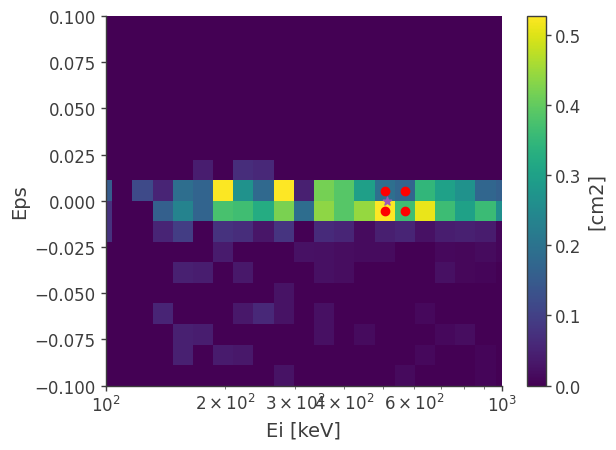

In [124]:
Ei0 = 511 * u.keV
Em0 = 511 * u.keV

fig, ax = plt.subplots()
dr.slice[:,:,60,:,:,0,0].project('Ei', 'Eps').draw(ax=ax)
ax.scatter(Ei0, dr.transform_Em_to_Eps(Em0, Ei0), marker='*', s=40, zorder=11)

target = {'Ei': Ei0, 'Em': Em0}
hist = dr.project('Ei', 'Eps')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
dr2.get_interp_response(target)

for e1 in dr2.neighbors['Ei']:
    for e2 in dr2.neighbors['Eps']:
        ax.scatter(e1, e2, c='r')

ax.set_ylim([-0.1, 0.1])
ax.set_xlim([100, 1000])
plt.show()

### Unbinned

In [20]:
# 511keV_spacecraftframe_injected.h5 file generated in `testing` branch with `511keV_injector.ipynb`
expectation = Histogram.open('../../unbinned/511keV_spacecraftframe_injected.h5')

(<Axes: xlabel='Phi [deg]'>, <ErrorbarContainer object of 3 artists>)

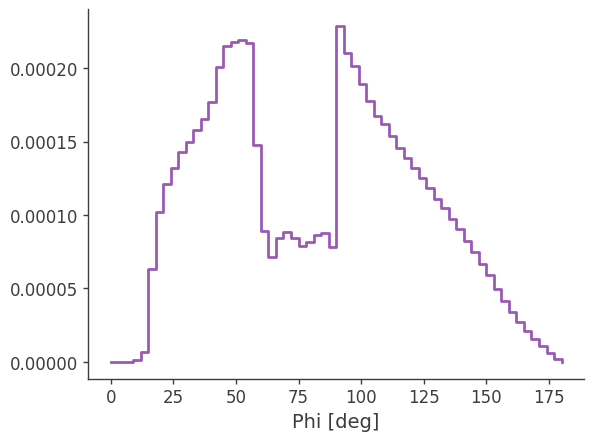

In [50]:
expectation.project('Phi').draw()

In [22]:
np.sum(expectation.project('Phi').contents)

<Quantity 0.00631258>

In [23]:
expectation.project('Phi', 'PsiChi').contents.shape

(60, 3072)

In [108]:
# Example: Create a 2D histogram PDF (20x20 bins)
hist = expectation.project('Phi', 'PsiChi').contents
hist /= hist.sum()  # Normalize to turn it into a valid probability distribution

# Define bin centers
x_centers = expectation.axes['Phi'].centers
y_centers = expectation.axes['PsiChi'].edges[:-1]

# Estimate bin widths (assuming evenly spaced centers)
x_width = np.diff(x_centers).mean()
y_width = np.diff(y_centers).mean()

# Generate marginal distribution over flattened array
flat_hist = hist.ravel()
indices = np.arange(flat_hist.size)

# Number of samples to generate
num_samples = 100000

# Sample from the histogram
chosen_indices = np.random.choice(indices, size=num_samples, p=flat_hist)
phi_bins, psichi_bins = np.unravel_index(chosen_indices, hist.shape)

# Optional: scale to actual bin coordinates
phi = phi_bins + np.random.rand(num_samples)  # Add jitter within bin
psichi = psichi_bins + np.random.rand(num_samples)

# Convert bin indices to coordinates with uniform random jitter within each bin
phi_samples = x_centers[phi_bins] + np.random.uniform(-x_width.value/2, x_width.value/2, size=num_samples) * x_width.unit
psichi_samples = y_centers[psichi_bins]     # y_centers are anyway integers aranged from 0 to 12*nside**2

energy_samples = np.random.normal(511, 0.6, num_samples)

In [122]:
# Define the resolution parameter (must match the one used in your histogram)
nside = 16

# Convert HEALPix indices to psi (colatitude) and chi (longitude)
psi_samples, chi_samples = hp.pix2ang(nside, psichi_samples) * u.rad

# Estimate angular resolution in radians
pixel_area = hp.nside2pixarea(nside) * u.sr  # steradians
pixel_radius = np.sqrt(pixel_area / np.pi) / 10  # approximate angular radius and divide jitter scale by 10

# Add uniform jitter within pixel resolution
psi_jitter = np.random.uniform(-pixel_radius.value, pixel_radius.value, size = psi_samples.shape) * pixel_radius.unit
chi_jitter = np.random.uniform(-pixel_radius.value, pixel_radius.value, size = chi_samples.shape) * pixel_radius.unit

# Apply jitter with boundary checks
psi_samples = np.clip(psi_samples + psi_jitter, 0, np.pi * psi_samples.unit)
chi_samples = (chi_samples + chi_jitter) % (2 * np.pi * chi_samples.unit)

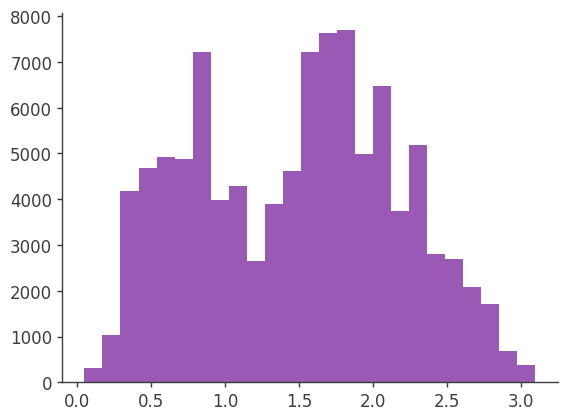

In [125]:
plt.hist(psi_samples)
plt.show()

In [124]:
data = {}
data['Energies'] = energy_samples
data['Phi'] = phi_samples
data['Phi local'] = psi_samples
data['Chi local'] = chi_samples

In [ ]:
# Spectral response calculations
Ntot = num_samples//10

# Phase space sampling edges
nbins_mu, nbins_sigma = 30, 30
pred_mu, pred_sigma = np.meshgrid(np.linspace(508, 514, nbins_mu), np.linspace(0.3, 1.2, nbins_sigma))

for i in range(nbins_mu):
    for j in range(nbins_sigma):
        # Initialize loglike with first term
        loglike = -Ntot

In [ ]:
# point_source = UnBinnedData(DATA_DIR / '511/inputs.yaml')
# data = point_source.get_dict_from_fits(DATA_DIR / '511/sources/511_testing_point_source_3months_unbinned_data_filtered_with_SAAcut.fits')

### PyTorch versions

In [22]:
import torch

In [23]:
def _get_vector(Phi_sc, Theta_sc):
    """
    Construct a 3D vector from sine-cosine representations of angular coordinates.

    The inputs, Phi_sc and Theta_sc, are expected to be produced by '_sc_stacker', so that each
    contains both the sine and cosine values of the corresponding angle.

    Parameters:
        Phi_sc (Tensor): Sine-cosine representation of the phi angle.
        Theta_sc (Tensor): Sine-cosine representation of the theta angle.

    Returns:
        Tensor: A 3D vector computed from the provided sine-cosine components.
    """
    x = Theta_sc[0] * Phi_sc[1]
    y = Theta_sc[0] * Phi_sc[0]
    z = Theta_sc[1]

    return torch.stack((x, y, z), dim=-1)

def _sc_stacker(t):
    """
    Create a sine-cosine tensor from an angle.

    Parameters:
        t (Tensor): A tensor of angles.

    Returns:
        Tensor: A vertically stacked tensor containing [sin(t), cos(t)].
    """
    return torch.vstack((torch.sin(t), torch.cos(t)))

def _convert_conventions(Nu_sc, Lambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc):
    """
    Convert classical to relative coordinate convention.
    
    Parameters:
        Nu_sc, Lambda_sc (Tensor): Sine-cosine representation of the initial photon direction in spacecraft coordinates.
        Ei (Tensor): Initial energy.
        Em (Tensor): Measured energy.
        Phi (Tensor): Scattering angle.
        Psi_sc, Chi_sc (Tensor): Sine-cosine representation of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Epsilon, Theta ARM, Zeta) in relative coordinates
    """
    Eps = Em/Ei - 1

    source = _get_vector(Nu_sc, Lambda_sc)
    scatter = _get_vector(Psi_sc, Chi_sc)

    Phi_geo = torch.arccos(torch.clip(torch.sum(source * scatter, axis=1), -1., 1.))

    xaxis = torch.tensor([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = torch.cross(pz, xaxis.expand_as(pz), dim=1)
    px /= torch.norm(px, dim=1, keepdim=True)
    py = torch.cross(pz, px, dim=1)
    py /= torch.norm(py, dim=1, keepdim=True)

    proj_x = torch.sum(scatter * px, dim=1)
    proj_y = torch.sum(scatter * py, dim=1)

    Zeta = torch.atan2(proj_y, proj_x)
    Zeta = torch.where(Zeta < 0, Zeta + 2*np.pi, Zeta)

    return (Eps, Phi_geo - Phi, Zeta)

def _reverse_conventions(Nu_sc, Lambda_sc, Ei, Eps, Phi, Theta, Zeta):
    """
    Convert relative to classical coordinate convention.
    
    Parameters:
        Nu_sc, Lambda_sc (Tensor): Sine-cosine representation of the initial photon direction in spacecraft coordinates.
        Ei (Tensor): Initial energy.
        Eps (Tensor): Relative measured energy.
        Phi (Tensor): Scattering angle.
        Theta, Zeta (Tensor): Relative representation of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Em, Psi, Chi) in classical coordinates
    """
    Em = Ei * (Eps + 1)

    Psi_sc = _sc_stacker(Zeta)
    Chi_sc = _sc_stacker(np.pi - (Theta + Phi))
    scatter_base = _get_vector(Psi_sc, Chi_sc)

    source = _get_vector(Nu_sc, Lambda_sc)
    xaxis = torch.tensor([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = torch.cross(pz, xaxis.expand_as(pz), dim=1)
    px /= torch.norm(px, dim=1, keepdim=True)
    py = torch.cross(pz, px, dim=1)
    py /= torch.norm(py, dim=1, keepdim=True)

    change_basis = torch.stack((px, py, pz), dim=2)
    scatter = torch.matmul(change_basis, scatter_base.unsqueeze(-1)).squeeze(-1)
    scatter /= torch.norm(scatter, dim=1, keepdim=True)

    Psi = torch.atan2(scatter[:, 1], scatter[:, 0])
    Psi = torch.where(Psi < 0, Psi + 2*np.pi, Psi)

    Chi = torch.acos(torch.clamp(scatter[:, 2], -1., 1.))

    return (Em, Psi, Chi)

In [ ]:
NuLambda_sc = torch.tensor([100])
Nu_sc, Lambda_sc = hp.pix2ang(nside=nside, ipix=NuLambda_sc)
Nu_sc = _sc_stacker(Nu_sc).to(torch.float32)
Lambda_sc = _sc_stacker(Lambda_sc).to(torch.float32)

Ei = 511
Eps = -0.002
Phi = torch.tensor(np.deg2rad(30, dtype=np.float32))
Theta = torch.tensor(np.deg2rad(15, dtype=np.float32))
Zeta = torch.tensor(np.deg2rad(10, dtype=np.float32))

Em, Psi_sc, Chi_sc = _reverse_conventions(Nu_sc, Lambda_sc, Ei, Eps, Phi, Theta, Zeta)
# print(Em, Psi_sc, Chi_sc)
Psi_sc = _sc_stacker(Psi_sc)
Chi_sc = _sc_stacker(Chi_sc)
_convert_conventions(Nu_sc, Lambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc)

(-0.0020000000000000018,
 tensor([0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618,
         0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618, 0.2618]),
 tensor([0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745,
         0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745, 0.1745,
         